# BIFROST reduction of simulated data

This notebook demonstrates the basic data reduction workflow for BIFROST.
It uses data that was simulated with McStas and a dedicated workflow that can process McStas data.

In [1]:
import numpy as np
import scipp as sc
import sciline

from ess import bifrost
from ess.bifrost.data import (
    simulated_elastic_incoherent_with_phonon,
    lookup_table_simulation
)
from ess.spectroscopy.types import *

Construct the workflow which is a [sciline.Pipeline](https://scipp.github.io/sciline/generated/classes/sciline.Pipeline.html) and encodes the entire reduction procedure.
We need to provide a couple of parameters so we can run the workflow:

In [2]:
workflow = bifrost.BifrostSimulationWorkflow()
# Set the input file name:
workflow[Filename[SampleRun]] = simulated_elastic_incoherent_with_phonon()
# Set the lookup table for frame unwrapping:
workflow[LookupTableFilename] = lookup_table_simulation()
# Set thresholds to mask wavelength regions with large uncertainties.
# For this example, we do not mask anything:
workflow[LookupTableRelativeErrorThreshold] = {
    'detector': np.inf,
    'normalization_monitor': np.inf,
}
# We need to read many objects from the file,
# keeping it open improves performance: (optional)
workflow[PreopenNeXusFile] = PreopenNeXusFile(True)
# We drop uncertainties where they would otherwise lead to correlations:
workflow[UncertaintyBroadcastMode] = UncertaintyBroadcastMode.drop

Next, draw the workflow as a graph to inspect the steps it will take to reduce the data.

Note the groups where entries are labeled with `(triplet)`. (These labels will be `(dim_0)` if you don't have [Pandas](https://pandas.pydata.org/) installed.)
These groups indicate functions that are applied separately to each detector triplet.

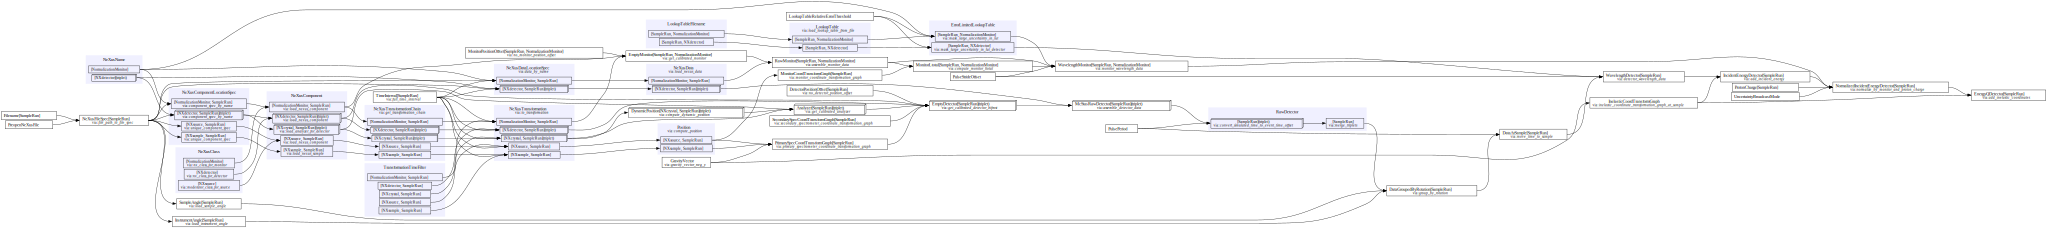

In [3]:
workflow.visualize(EnergyQDetector[SampleRun], compact=True, graph_attr={"rankdir": "LR"})

We are ready to compute the reduced data.
We use the naive scheduler of sciline because it tends to perform better for BIFROST than the [Dask](https://docs.dask.org/en/stable/index.html) scheduler.
But this is optional.

In [4]:
scheduler = sciline.scheduler.NaiveScheduler()
data = workflow.compute(EnergyQDetector[SampleRun], scheduler=scheduler)

The result contains coordinates for the sample table and detector rotation angles `a3` and `a4`, respectively.
It also contains event coordinates for `energy_transfer` and two momentum transfers, one in the lab frame and one in the sample table frame.

In [5]:
data

<scipp.DataArray>
Dimensions: Sizes[arc:5, channel:9, tube:3, length:100, a4:2, a3:180, ]
Coordinates:
* L1                        float64              [m]  ()  161.999
* Ltotal                    float64              [m]  ()  161.999
* a3                        float32            [deg]  (a3)  [0, 1, ..., 178, 179]
* a4                        float32            [deg]  (a4)  [90, 95]
* arc                         int64        <no unit>  (arc, channel)  [0, 0, ..., 4, 4]
* channel                     int64        <no unit>  (arc, channel)  [0, 1, ..., 7, 8]
* detector_number             int64        <no unit>  (arc, channel, tube, length)  [1, 2, ..., 13499, 13500]
* secondary_flight_time     float64             [ms]  (arc, channel, a4, tube, length)  [3.198, 3.198, ..., 3.37926, 3.37926]
Data:
                          DataArrayView        <no unit>  (arc, channel, tube, length, a4, a3)  binned data: dim='event', content=DataArray(
          dims=(event: 2497491),
          data=float64*counts*s^-1*A^-1],
          coords={'energy_transfer':float64[meV], 'sample_table_momentum_transfer':vector3[1/Å]},
          masks={'_monitor_mask':bool})

We can plot the counts as a function of energy transfer and $a_3$ by removing the unused dimensions.
As expected, it is independent of $a_3$.

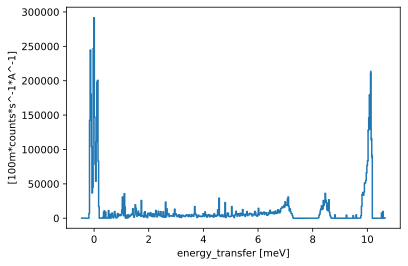

In [6]:
(
    data
    .bins.concat()
    .hist(energy_transfer=500)
).plot()

We can also plot the counts as a function of the momentum transfer in the sample table frame $Q$.
For this, we first need to create a 2D slice in $Q$ and $\Delta E$.
For simplicity, we use the x and z axes or $Q$ (see https://scipp.github.io/scippneutron/user-guide/coordinate-transformations.html for definitions).
But we could use any other normalized, orthogonal vectors in the dot products.

We can make a second plot using one of the projections and the energy transfer.

The plots are a bit coarse because we only used two triplets.

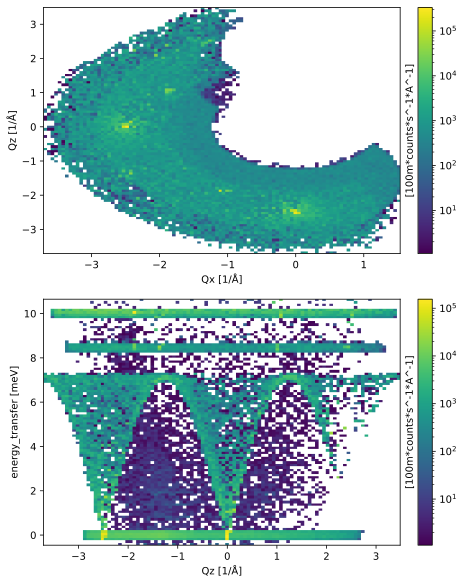

In [7]:
d = data.bins.concat().copy()
x = sc.vector([1, 0, 0])
z = sc.vector([0, 0, 1])
d.bins.coords['Qx'] = sc.dot(x, d.bins.coords['sample_table_momentum_transfer'])
d.bins.coords['Qz'] = sc.dot(z, d.bins.coords['sample_table_momentum_transfer'])
d.hist(Qz=100, Qx=100).plot(norm='log') / d.hist(energy_transfer=100, Qz=100).plot(norm='log')